## 可视化训练集

In [1]:
%matplotlib inline

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
torch.set_printoptions(edgeitems=2)
torch.manual_seed(123456)

print("")

### 1. 加载数据集

通过前一篇文章，我们已经把处理过的数据集保存到了文件中。

In [2]:
ds_file_path = "../../../data/datasets/emotion/embedding_ds"

# 从磁盘中加载数据集
ds = load_from_disk(ds_file_path)

# 设置数据集数据的格式为torch
# ds.set_format("torch")

# 重置格式
# ds.reset_format()

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
})

In [4]:
type(ds["train"]["hidden_state"])

torch.Tensor

In [5]:
type(ds["train"]["label"])

torch.Tensor

我们在识别文本的类型（文本分类）时用到的字段有2个：`hidden_state`和`label`。   
根据句子的特征值(hidden_state)，通过学习得到其分类(label)。 `Y = func(X)`

现在先获取一下特征矩阵。

In [6]:
# 训练矩阵
X_train = np.array(ds["train"]["hidden_state"])
Y_train = np.array(ds["train"]["label"])

# 验证矩阵
X_valid = np.array(ds["validation"]["hidden_state"])
Y_valid = np.array(ds["validation"]["label"])

# 测试矩阵
X_test = np.array(ds["test"]["hidden_state"])
Y_test = np.array(ds["test"]["label"])

In [7]:
# 查看训练矩阵的大小
X_train.shape, Y_train.shape

((16000, 768), (16000,))

### 2. 使用umap可视化数据集

句子的特征值是一个`768`维度的数据，想要展示它特别简单。如果是三维的那还好展示。     
但是我们可以使用`UMAP`算法将这个`768`维的向量投影到一个`2D`平面上。    
`UMAP`在特征缩放到`[0, 1]`区间的时候效果最佳，隐藏我们首先要将特征向量运用一下`MinMaxScaler`.

安装`umap-learn`库：`pip install umap-learn`

In [8]:
# !pip install umap-learn

In [9]:
from umap import UMAP
# from sklearn.preprocessing import MinMaxScaler

In [10]:
# 也可以直接导入MinMaxScaler: sklearn.preprocessing import MinMaxScaler

class MinMaxScaler:  
    def __init__(self, feature_range=(0, 1)):  
        self.feature_range = feature_range  
        self.min_ = None  
        self.scale_ = None  
  
    def fit(self, X):  
        """  
        计算数据的最小值和缩放比例  
        """  
        self.min_ = np.min(X, axis=0)  
        data_range = np.max(X, axis=0) - self.min_  
        self.scale_ = (self.feature_range[1] - self.feature_range[0]) / data_range  
        return self  
  
    def transform(self, X):  
        """  
        应用缩放转换  
        """  
        if self.min_ is None or self.scale_ is None:  
            raise ValueError("Scaler has not been fitted yet.")  
        return self.feature_range[0] + (X - self.min_) * self.scale_  
  
    def fit_transform(self, X):  
        """  
        先拟合数据，然后应用转换  
        """  
        return self.fit(X).transform(X)

In [11]:
# 把训练集的特征值缩放到[0,1]区间
X_scaled = MinMaxScaler().fit_transform(X_train)

In [12]:
np.max(X_scaled), np.max(X_train)

(1.0, 4.587813)

In [13]:
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [14]:
mapper.embedding_.shape

(16000, 2)

In [15]:
# 创建一个DataFrame
df_embedding = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_embedding["label"] = Y_train

In [16]:
# 查看头部
df_embedding.head()

,X,Y,label
0,10.614461,-1.166048,0
1,-4.345194,-1.895818,0
2,9.002156,1.963330,3
3,-2.243790,-2.902194,2
4,-5.046133,-2.940609,3


现在我们得到了一个数组，该数组具有相同的训练样本数，但值有2个特征，而不是最开始的`768`个特征了！    
我们现在绘制每个分类的点密度图：

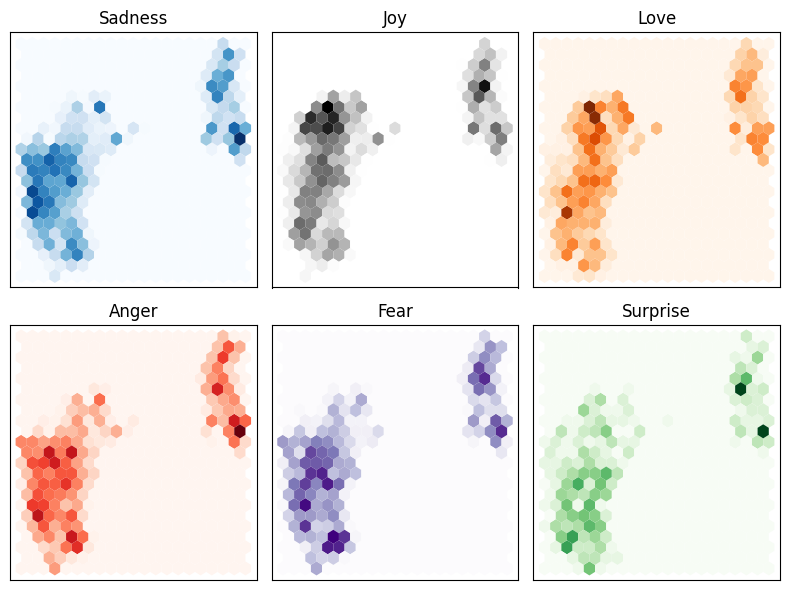

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6))

# 开始的2行3列，如果不调用flatten就需要：axes[r][c]才能操作axe
axes = axes.flatten()

# 6种情绪的名称     
labels = ds["train"].features["label"].names
         #['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
# 颜色使用的是：白色-->color的渐变色，显示效果最佳
cmaps = ["Blues", "Greys", "Oranges", "Reds", "Purples", "Greens"]

# 开始画出6个类型的子图
for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_embedding_sub = df_embedding.query(f"label == {i}")
    # hexbin绘制二维数据的六边形箱图
    # hexbin函数将数据按照坐标分为多个小六边形区域，并根据每个区域内数据点的数量进行不同的着色，以展示数据的分布情况。
    axes[i].hexbin(df_embedding_sub["X"], df_embedding_sub["Y"], cmap=cmap, gridsize=20, linewidths=(0,))
    # 设置标题
    axes[i].set_title(label.title())
    # 设置x、y坐标为空
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout()
# 显示图像
plt.show()

> 注意这些数据是投影到较低维度的结果。
> 某些类别重叠并不意味着，它们在原始空间中不能区分。如果在投影空间中类别都是可区分的，那么它们在原始空间中也是可区分的。